## Credit Risk Prediction using Machine Learning
Project Overview
The goal of this project is to predict whether a loan applicant is likely to default or not based on financial and demographic information.

Machine learning models such as Logistic Regression and Decision Tree are used to classify loan applicants into risky or safe borrowers.



# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Plot style
sns.set_style('whitegrid')

# Load Train Dataset

In [2]:
# Train dataset (with Loan_Status)
df_train = pd.read_csv(r"C:\Users\Public\Intern-Tasks\Credit Risk Prediction\train_u6lujuX_CVtuZ9i.csv")

# Clean column names (remove spaces)
df_train.columns = df_train.columns.str.strip()

# Check first 5 rows
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Handle Missing Values

In [3]:
# Numerical columns
num_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

# Categorical columns
cat_cols = ['Gender', 'Dependents', 'Self_Employed']
for col in cat_cols:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

# Verify missing values
df_train.isnull().sum()

Loan_ID              0
Gender               0
Married              3
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Numerical columns (LoanAmount, Loan_Amount_Term, Credit_History) are filled with median values. Categorical columns (Gender, Dependents, Self_Employed) are filled with mode (most frequent) values.

This ensures the dataset has no missing values before training the model.

# Exploratory Data Analysis (EDA)

### Loan Amount Distribution

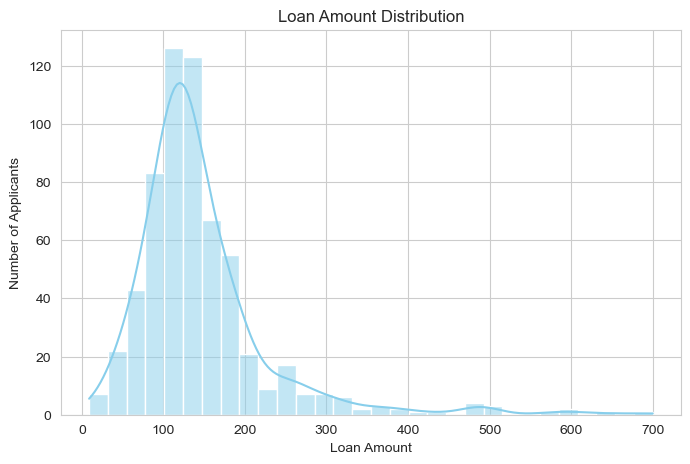

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df_train['LoanAmount'], kde=True, bins=30, color='skyblue')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Applicants')
plt.show()

The distribution of loan amounts shows how much applicants are requesting.  
Most applicants request loans around the median value.

### Education vs Loan Status

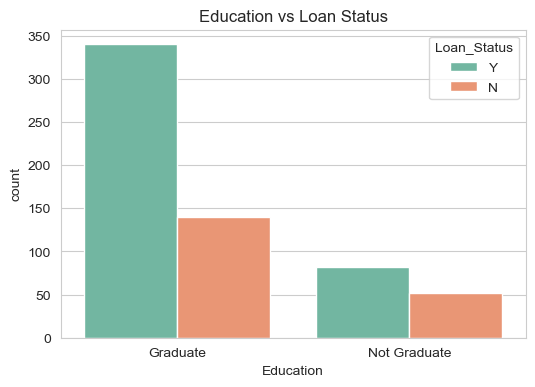

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df_train, palette='Set2')
plt.title('Education vs Loan Status')
plt.show()

Graduates have higher chances of loan approval compared to non-graduates, indicating education may impact loan decisions.

### Applicant Income Distribution

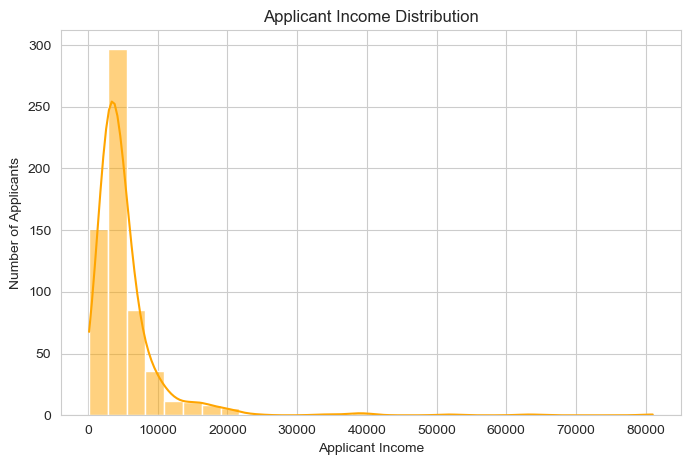

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df_train['ApplicantIncome'], bins=30, kde=True, color='orange')
plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')
plt.ylabel('Number of Applicants')
plt.show()

This distribution shows how income varies among applicants and its possible effect on loan approval.

### Credit History vs Loan Status

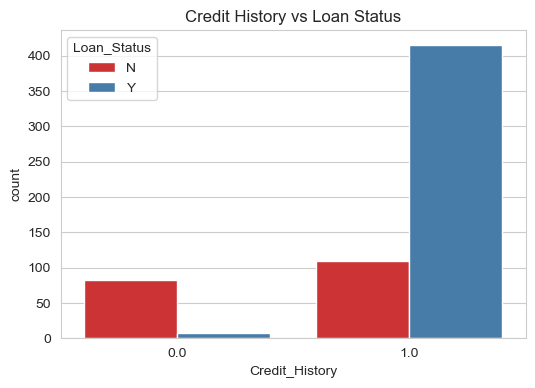

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df_train, palette='Set1')
plt.title('Credit History vs Loan Status')
plt.show()

Applicants with good credit history (1) are more likely to get loans approved, showing strong correlation between credit history and loan approval.

### Property Area vs Loan Status

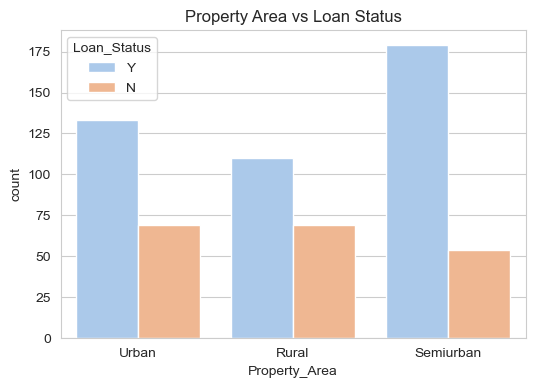

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df_train, palette='pastel')
plt.title('Property Area vs Loan Status')
plt.show()

Applicants from semi-urban and urban areas get more approvals compared to rural areas.

# Encode Categorical Variables

In [14]:
le = LabelEncoder()

# Encode target
df_train['Loan_Status'] = le.fit_transform(df_train['Loan_Status'])  # Y: 1 = Approved, 0 = Not Approved

# Encode categorical features
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']:
    df_train[col] = le.fit_transform(df_train[col])

df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# Split Data into Features and Target

In [16]:
X = df_train.drop(columns=['Loan_ID', 'Loan_Status'])
y = df_train['Loan_Status']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_val_scaled)

# Train Decision Tree

In [21]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_dt))

Decision Tree Accuracy: 0.6910569105691057
Confusion Matrix:
 [[23 20]
 [18 62]]


# Test Dataset Predictions

In [26]:
df_test = pd.read_csv(r"C:\Users\Public\Intern-Tasks\Credit Risk Prediction\test_Y3wMUE5_7gLdaTN.csv")
df_test.columns = df_test.columns.str.strip()

# Handle missing values in test
num_cols_test = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_cols_test:
    df_test[col] = df_test[col].fillna(df_test[col].median())

cat_cols_test = ['Gender', 'Dependents', 'Self_Employed']
for col in cat_cols_test:
    df_test[col] = df_test[col].fillna(df_test[col].mode()[0])

# Encode categorical features same as train
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']:
    df_test[col] = le.fit_transform(df_test[col])

# Prepare test features (match train columns)
X_test = df_test.drop(columns=['Loan_ID'])[X_train.columns]
X_test_scaled = scaler.transform(X_test)  # scale same as train

# Predict Loan_Status using Logistic Regression
df_test['Loan_Status'] = lr_model.predict(X_test_scaled)
df_test['Loan_Status'] = le.inverse_transform(df_test['Loan_Status'])  # convert 1/0 to A/N

# Save predictions
df_test[['Loan_ID', 'Loan_Status']].to_csv('loan_predictions.csv', index=False)

print("✅ Test predictions saved to 'loan_predictions.csv'")

✅ Test predictions saved to 'loan_predictions.csv'
